# Step 3: Protein–Protein Interaction Network Analysis

Inputs from Steps 1 & 2:
- `wgcna_module_assignments.csv` — WGCNA module memberships
- `enrichment_results.csv` — Fisher's exact test enrichment results
- `data/nsc_genes_t1_0.csv` — NSC query genes (selection_frequency == 1.0)

Pipeline: STRING API → hub metrics → cross-reference with enriched modules → priority candidates

In [1]:
import pandas as pd
import numpy as np
import requests
import networkx as nx
import json
import matplotlib.pyplot as plt

# ── Load inputs from Steps 1 & 2 ─────────────────────────────────────────────
nsc_genes  = pd.read_csv('data/nsc_genes_t1_0.csv')
nsc_query  = nsc_genes[nsc_genes['selection_frequency'] == 1.0]['gene_id'].tolist()
print(f"NSC query genes (selection_frequency == 1.0): {len(nsc_query)}")

modules = pd.read_csv('wgcna_module_assignments.csv')
print(f"WGCNA modules loaded: {len(modules):,} genes across {modules['module_color'].nunique()} modules")

enrichment = pd.read_csv('enrichment_results.csv')
print(f"\nEnrichment results ({len(enrichment)} modules tested):")
print(enrichment[['module_color', 'fold_enrichment', 'fdr', 'significant']].to_string(index=False))

NSC query genes (selection_frequency == 1.0): 392
WGCNA modules loaded: 10,000 genes across 10 modules

Enrichment results (10 modules tested):
module_color  fold_enrichment          fdr  significant
       black           4.9622 9.585631e-09         True
        blue           2.5093 2.140470e-07         True
       brown           0.9370 1.000000e+00        False
       green           0.8530 1.000000e+00        False
        pink           0.7992 1.000000e+00        False
         red           0.7104 1.000000e+00        False
   turquoise           0.9398 1.000000e+00        False
        grey           0.7392 1.000000e+00        False
      yellow           0.3961 1.000000e+00        False
     magenta           0.0000 1.000000e+00        False


## Step 1 — Query STRING API

In [2]:
STRING_API = 'https://string-db.org/api'
SPECIES    = 9606   # Homo sapiens
CALLER     = 'pstat135_ppi_analysis'

# ── Step 1a: Map Ensembl IDs → STRING identifiers ────────────────────────────
print(f"Mapping {len(nsc_query)} Ensembl IDs to STRING identifiers...")
map_resp = requests.post(
    f'{STRING_API}/json/get_string_ids',
    data={
        'identifiers'    : '\r'.join(nsc_query),
        'species'        : SPECIES,
        'limit'          : 1,
        'caller_identity': CALLER,
    }
)
map_resp.raise_for_status()

id_map     = {}   # ensembl_id → string_id
symbol_map = {}   # ensembl_id → gene symbol
for hit in map_resp.json():
    eid = hit['queryItem']
    id_map[eid]     = hit['stringId']
    symbol_map[eid] = hit.get('preferredName', eid)

n_mapped   = len(id_map)
n_unmapped = len(nsc_query) - n_mapped
print(f"Mapped:   {n_mapped}/{len(nsc_query)} genes")
print(f"Unmapped: {n_unmapped}")

# ── Step 1b: Retrieve interactions (medium confidence, score ≥ 400) ───────────
string_ids = list(id_map.values())
print(f"\nRetrieving STRING network (required_score=400)...")
net_resp = requests.post(
    f'{STRING_API}/json/network',
    data={
        'identifiers'    : '\r'.join(string_ids),
        'species'        : SPECIES,
        'required_score' : 400,
        'caller_identity': CALLER,
    }
)
net_resp.raise_for_status()
edges_raw = net_resp.json()
print(f"Edges returned: {len(edges_raw)}")

# ── Step 1c: Build networkx undirected graph ───────────────────────────────────
rev_map = {v: k for k, v in id_map.items()}   # string_id → ensembl_id

G = nx.Graph()
for eid, sid in id_map.items():
    G.add_node(eid, string_id=sid, gene_symbol=symbol_map[eid])

for edge in edges_raw:
    eid_a = rev_map.get(edge['stringId_A'])
    eid_b = rev_map.get(edge['stringId_B'])
    if eid_a and eid_b and eid_a != eid_b:
        score = edge.get('score', edge.get('combined_score', 0))
        G.add_edge(eid_a, eid_b, weight=score)

n_connected = sum(1 for n in G.nodes() if G.degree(n) > 0)
n_isolated  = sum(1 for n in G.nodes() if G.degree(n) == 0)

print(f"\nGraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected nodes: {n_connected}  |  Isolated nodes: {n_isolated}")
print(f"Network density: {nx.density(G):.5f}")

Mapping 392 Ensembl IDs to STRING identifiers...
Mapped:   384/392 genes
Unmapped: 8

Retrieving STRING network (required_score=400)...
Edges returned: 688

Graph: 384 nodes, 688 edges
Connected nodes: 274  |  Isolated nodes: 110
Network density: 0.00936


## Step 2 — Calculate Hub Metrics

In [3]:
# ── Step 2: Degree + betweenness centrality ───────────────────────────────────
print("Computing degree...")
degree_dict = dict(G.degree())

print("Computing betweenness centrality (normalized)...")
bc_dict = nx.betweenness_centrality(G, normalized=True)

metrics = pd.DataFrame({
    'gene_id'                : list(degree_dict.keys()),
    'gene_symbol'            : [G.nodes[n].get('gene_symbol', n) for n in degree_dict],
    'degree'                 : list(degree_dict.values()),
    'betweenness_centrality' : [bc_dict[n] for n in degree_dict],
})
metrics = metrics.sort_values('degree', ascending=False).reset_index(drop=True)

# Hub threshold: 90th percentile of degree among connected nodes
connected_degrees = metrics.loc[metrics['degree'] > 0, 'degree']
hub_threshold     = np.percentile(connected_degrees, 90)
metrics['is_hub'] = metrics['degree'] >= hub_threshold
n_hubs = int(metrics['is_hub'].sum())

print(f"\nHub threshold (90th percentile of connected-node degrees): degree ≥ {hub_threshold:.1f}")
print(f"Hub genes: {n_hubs} / {(metrics['degree'] > 0).sum()} connected nodes")
print(f"\nTop 20 by degree:")
print(metrics[['gene_symbol', 'degree', 'betweenness_centrality', 'is_hub']].head(20).to_string(index=False))

Computing degree...
Computing betweenness centrality (normalized)...

Hub threshold (90th percentile of connected-node degrees): degree ≥ 13.0
Hub genes: 32 / 274 connected nodes

Top 20 by degree:
gene_symbol  degree  betweenness_centrality  is_hub
      EP300      31                0.054147    True
       EZH2      30                0.039911    True
        ATM      30                0.039483    True
      BRCA2      26                0.030649    True
     H2BC21      24                0.020475    True
       KRAS      23                0.042391    True
       HMMR      19                0.023255    True
     H2BC12      19                0.016979    True
      BARD1      19                0.005702    True
      PALB2      18                0.024198    True
      KMT2C      18                0.012569    True
      NOP58      18                0.025414    True
      STAT1      18                0.033805    True
      CENPE      18                0.012296    True
     NUSAP1      16   

## Step 3 — Cross-Reference with Enriched WGCNA Modules

In [4]:
# ── Step 3: Hubs ∩ significantly enriched WGCNA module genes ─────────────────
sig_modules = enrichment[enrichment['significant'] == True].copy()
print(f"Significantly enriched modules (FDR < 0.05): {len(sig_modules)}")

enriched_gene_set = set()
gene_to_module    = {}   # gene_id → module_color

for _, row in sig_modules.iterrows():
    if pd.notna(row.get('nsc_genes_in_module', '')) and row['nsc_genes_in_module']:
        for g in str(row['nsc_genes_in_module']).split(';'):
            g = g.strip()
            if g:
                enriched_gene_set.add(g)
                gene_to_module[g] = row['module_color']

print(f"Genes in significantly enriched modules: {len(enriched_gene_set)}")

hub_gene_set  = set(metrics.loc[metrics['is_hub'], 'gene_id'])
priority_set  = hub_gene_set & enriched_gene_set
hub_only      = hub_gene_set - enriched_gene_set
enriched_only = enriched_gene_set - hub_gene_set

print(f"\nHub genes (top 10% degree):                    {len(hub_gene_set)}")
print(f"Enriched module genes:                          {len(enriched_gene_set)}")
print(f"Priority candidates (hub ∩ enriched module):   {len(priority_set)}")
print(f"Hubs not in enriched module:                    {len(hub_only)}")
print(f"Enriched module genes not hubs:                 {len(enriched_only)}")

# Annotate metrics table
metrics['in_enriched_module']    = metrics['gene_id'].isin(enriched_gene_set)
metrics['enriched_module_color'] = metrics['gene_id'].map(gene_to_module)
metrics['priority_candidate']    = metrics['gene_id'].isin(priority_set)

if priority_set:
    print(f"\nPriority candidates:")
    print(
        metrics[metrics['priority_candidate']][
            ['gene_symbol', 'gene_id', 'degree', 'betweenness_centrality', 'enriched_module_color']
        ].to_string(index=False)
    )
else:
    print("\nNo priority candidates at current thresholds.")

Significantly enriched modules (FDR < 0.05): 2
Genes in significantly enriched modules: 62

Hub genes (top 10% degree):                    32
Enriched module genes:                          62
Priority candidates (hub ∩ enriched module):   7
Hubs not in enriched module:                    25
Enriched module genes not hubs:                 55

Priority candidates:
gene_symbol         gene_id  degree  betweenness_centrality enriched_module_color
      EP300 ENSG00000100393      31                0.054147                  blue
       EZH2 ENSG00000106462      30                0.039911                  blue
        ATM ENSG00000149311      30                0.039483                  blue
      KMT2C ENSG00000055609      18                0.012569                  blue
     FANCD2 ENSG00000144554      15                0.017975                  blue
       AGO3 ENSG00000126070      13                0.010510                  blue
      NCAPH ENSG00000121152      13                0.002360 

## Step 4 — Save Outputs

In [5]:
# ── Step 4: ppi_hub_genes.csv + ppi_network.graphml ──────────────────────────
hub_output = metrics[[
    'gene_id', 'gene_symbol', 'degree', 'betweenness_centrality',
    'in_enriched_module', 'enriched_module_color', 'priority_candidate'
]].copy()
hub_output.to_csv('ppi_hub_genes.csv', index=False)
print(f"Saved: ppi_hub_genes.csv  ({len(hub_output):,} genes)")

nx.write_graphml(G, 'ppi_network.graphml')
print(f"Saved: ppi_network.graphml  ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")

Saved: ppi_hub_genes.csv  (384 genes)
Saved: ppi_network.graphml  (384 nodes, 688 edges)


## Step 5 — Diagnostics and Plots

Saved: step3_diagnostics.json
{
  "n_genes_queried": 392,
  "n_genes_mapped_to_string": 384,
  "n_edges_returned": 688,
  "network_density": 0.009356,
  "n_isolated_nodes": 110,
  "n_hub_genes_top10pct": 32,
  "n_priority_candidates": 7,
  "hub_genes_not_in_enriched_module": [
    "ABCE1",
    "ASH1L",
    "BARD1",
    "BRCA2",
    "CCNF",
    "CENPE",
    "CEP55",
    "CREB1",
    "H2AC14",
    "H2BC12",
    "H2BC21",
    "HMMR",
    "HSPA8",
    "KRAS",
    "MKI67",
    "NCAPG",
    "NOL6",
    "NOP58",
    "NUSAP1",
    "PALB2",
    "RSL1D1",
    "SETD2",
    "SETX",
    "STAT1",
    "TOPBP1"
  ],
  "enriched_module_genes_not_hubs": [
    "ABHD17B",
    "AK3",
    "ALCAM",
    "ASPH",
    "ATAD5",
    "BAZ2A",
    "CADM1",
    "CENPU",
    "CNTRL",
    "CORO1B",
    "CSAD",
    "CYP20A1",
    "ESF1",
    "FER",
    "GTF2H2C",
    "HMGB1",
    "ILK",
    "LPP",
    "MARCHF8",
    "NAV1",
    "NBEAL1",
    "OPHN1",
    "PAK2",
    "PCDHGB1",
    "PHF3",
    "PIWIL4",
    "PKN2",
    "

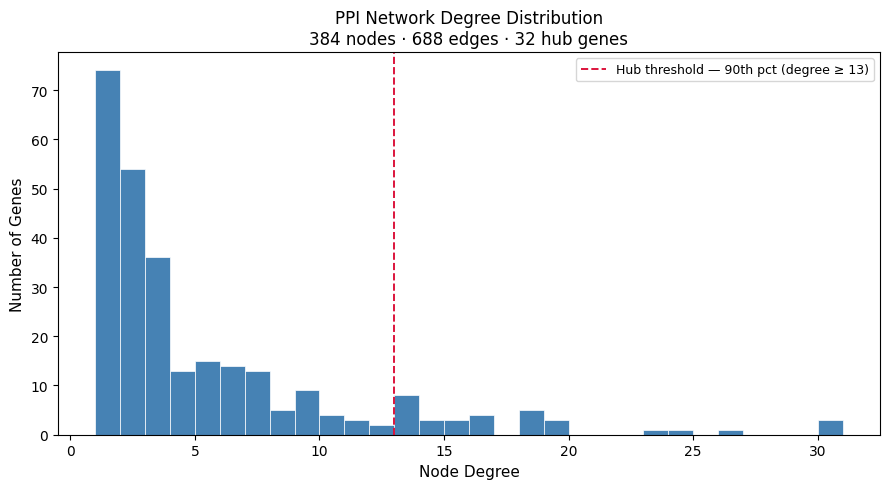

Saved: ppi_degree_distribution.png


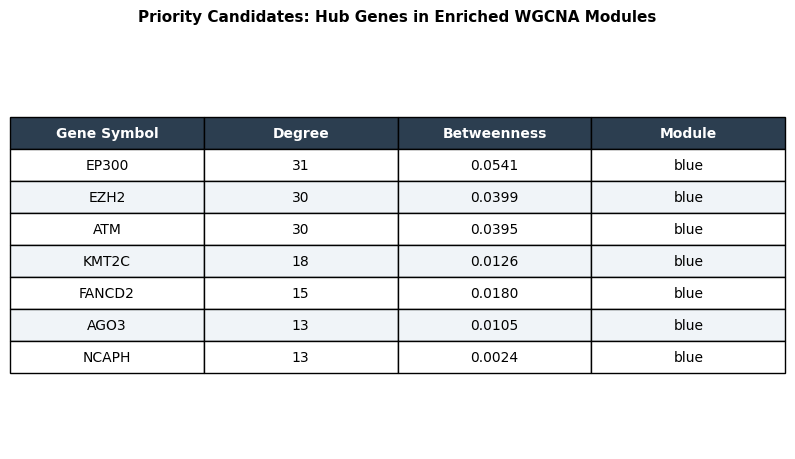

Saved: priority_candidates_table.png


In [6]:
# ── Step 5a: step3_diagnostics.json ──────────────────────────────────────────
priority_rows = metrics[metrics['priority_candidate']].copy()

priority_list = [
    {
        'gene_id'                : r['gene_id'],
        'gene_symbol'            : r['gene_symbol'],
        'degree'                 : int(r['degree']),
        'betweenness_centrality' : float(r['betweenness_centrality']),
        'enriched_module_color'  : str(r['enriched_module_color']) if pd.notna(r['enriched_module_color']) else None,
    }
    for _, r in priority_rows.iterrows()
]

hub_not_enriched = sorted(
    metrics.loc[metrics['is_hub'] & ~metrics['in_enriched_module'], 'gene_symbol'].tolist()
)
enriched_not_hub = sorted(
    metrics.loc[metrics['in_enriched_module'] & ~metrics['is_hub'], 'gene_symbol'].tolist()
)

diagnostics = {
    'n_genes_queried'                  : len(nsc_query),
    'n_genes_mapped_to_string'         : n_mapped,
    'n_edges_returned'                 : G.number_of_edges(),
    'network_density'                  : round(nx.density(G), 6),
    'n_isolated_nodes'                 : n_isolated,
    'n_hub_genes_top10pct'             : n_hubs,
    'n_priority_candidates'            : len(priority_list),
    'priority_candidates'              : priority_list,
    'hub_genes_not_in_enriched_module' : hub_not_enriched,
    'enriched_module_genes_not_hubs'   : enriched_not_hub,
}

with open('step3_diagnostics.json', 'w') as f:
    json.dump(diagnostics, f, indent=2)
print("Saved: step3_diagnostics.json")
print(json.dumps({k: v for k, v in diagnostics.items() if k != 'priority_candidates'}, indent=2))

# ── Step 5b: ppi_degree_distribution.png ─────────────────────────────────────
connected_degs = [d for _, d in G.degree() if d > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(connected_degs, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(hub_threshold, color='crimson', linestyle='--', linewidth=1.4,
           label=f'Hub threshold — 90th pct (degree ≥ {hub_threshold:.0f})')
ax.set_xlabel('Node Degree', fontsize=11)
ax.set_ylabel('Number of Genes', fontsize=11)
ax.set_title(
    f'PPI Network Degree Distribution\n'
    f'{G.number_of_nodes()} nodes · {G.number_of_edges()} edges · {n_hubs} hub genes',
    fontsize=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ppi_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ppi_degree_distribution.png")

# ── Step 5c: priority_candidates_table.png ────────────────────────────────────
if len(priority_list) > 0:
    tbl_data = priority_rows[
        ['gene_symbol', 'degree', 'betweenness_centrality', 'enriched_module_color']
    ].copy().sort_values('degree', ascending=False).reset_index(drop=True)
    tbl_data['betweenness_centrality'] = tbl_data['betweenness_centrality'].map('{:.4f}'.format)
    tbl_data.columns = ['Gene Symbol', 'Degree', 'Betweenness', 'Module']

    fig2, ax2 = plt.subplots(figsize=(8, max(2.5, len(tbl_data) * 0.5 + 1.2)))
    ax2.axis('off')
    tbl = ax2.table(
        cellText=tbl_data.values,
        colLabels=tbl_data.columns,
        cellLoc='center',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.7)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#f0f4f8')
    ax2.set_title(
        'Priority Candidates: Hub Genes in Enriched WGCNA Modules',
        fontsize=11, fontweight='bold', pad=14
    )
    plt.tight_layout()
    plt.savefig('priority_candidates_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: priority_candidates_table.png")
else:
    print("No priority candidates — skipping table plot.")
    print("(Hub genes and enriched module genes do not overlap at current FDR threshold.)")